# Taller 1 - Sistemas de Recomendacion 

ALISON DAIANA ARISTIZABAL GARCIA

SAMUEL CHARRY TOBAR

MARIA JOSE MANTILLA VARGAS

JERONIMO VASQUEZ PONCE - 202223824

SANTIAGO PALACIOS LOAIZA - 202523012

In [29]:
import os
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
from scipy.stats import pearsonr

# Configuración para gráficos
sns.set_style("whitegrid")
sns.set_palette("husl")

## 1. Exploracion del Dataset

In [4]:
# Ruta al directorio de datos
DAT_DIR = './dat'

# Carga de CSVs
tag = pd.read_csv(os.path.join(DAT_DIR, 'tag.csv'))
rating = pd.read_csv(os.path.join(DAT_DIR, 'rating.csv'))
movie = pd.read_csv(os.path.join(DAT_DIR, 'movie.csv'))
link = pd.read_csv(os.path.join(DAT_DIR, 'link.csv'))
genome_scores = pd.read_csv(os.path.join(DAT_DIR, 'genome_scores.csv'))
genome_tags = pd.read_csv(os.path.join(DAT_DIR, 'genome_tags.csv'))

# Resumen de carga
datasets = {'tag': tag, 'rating': rating, 'movie': movie, 'link': link, 'genome_scores': genome_scores, 'genome_tags': genome_tags}
for name, df in datasets.items():
    print(f"{name}: {len(df):,} filas, columnas: {list(df.columns)}")

tag: 465,564 filas, columnas: ['userId', 'movieId', 'tag', 'timestamp']
rating: 20,000,263 filas, columnas: ['userId', 'movieId', 'rating', 'timestamp']
movie: 27,278 filas, columnas: ['movieId', 'title', 'genres']
link: 27,278 filas, columnas: ['movieId', 'imdbId', 'tmdbId']
genome_scores: 11,709,768 filas, columnas: ['movieId', 'tagId', 'relevance']
genome_tags: 1,128 filas, columnas: ['tagId', 'tag']


### Estadísticas descriptivas (media, mediana, moda, desviación estándar)

In [5]:
# rating.csv - columna rating
print("=== rating (rating.csv) ===")
print(f"Media: {rating['rating'].mean():.4f}")
print(f"Mediana: {rating['rating'].median():.4f}")
print(f"Moda: {rating['rating'].mode().values}")
print(f"Desv. estándar: {rating['rating'].std():.4f}")
#print(rating['rating'].describe())

=== rating (rating.csv) ===
Media: 3.5255
Mediana: 3.5000
Moda: [4.]
Desv. estándar: 1.0520


In [6]:
# genome_scores.csv - columna relevance
print("=== relevance (genome_scores.csv) ===")
print(f"Media: {genome_scores['relevance'].mean():.4f}")
print(f"Mediana: {genome_scores['relevance'].median():.4f}")
print(f"Moda (valor más frecuente): {genome_scores['relevance'].mode().values}")
print(f"Desv. estándar: {genome_scores['relevance'].std():.4f}")
#print(genome_scores['relevance'].describe())

=== relevance (genome_scores.csv) ===
Media: 0.1165
Mediana: 0.0565
Moda (valor más frecuente): [0.014]
Desv. estándar: 0.1542


In [7]:
# Conteos por usuario y por película (actividad)
ratings_per_user = rating.groupby('userId').size()
ratings_per_movie = rating.groupby('movieId').size()

print("=== Ratings por usuario ===")
print(f"Media: {ratings_per_user.mean():.2f}")
print(f"Mediana: {ratings_per_user.median():.2f}")
print(f"Moda: {ratings_per_user.mode().values}")
print(f"Desv. estándar: {ratings_per_user.std():.2f}")

print("\n=== Ratings por película ===")
print(f"Media: {ratings_per_movie.mean():.2f}")
print(f"Mediana: {ratings_per_movie.median():.2f}")
print(f"Moda: {ratings_per_movie.mode().values}")
print(f"Desv. estándar: {ratings_per_movie.std():.2f}")

=== Ratings por usuario ===
Media: 144.41
Mediana: 68.00
Moda: [20]
Desv. estándar: 230.27

=== Ratings por película ===
Media: 747.84
Mediana: 18.00
Moda: [1]
Desv. estándar: 3085.82


In [8]:
# Categóricas: moda y frecuencias (tag, genres)
print("=== tag (tag.csv) - moda y top 5 ===")
print(tag['tag'].value_counts().head())

print("\n=== genres (movie.csv) - moda y top 5 ===")
print(movie['genres'].value_counts().head())

=== tag (tag.csv) - moda y top 5 ===
tag
sci-fi             3384
based on a book    3281
atmospheric        2917
comedy             2779
action             2657
Name: count, dtype: int64

=== genres (movie.csv) - moda y top 5 ===
genres
Drama            4520
Comedy           2294
Documentary      1942
Comedy|Drama     1264
Drama|Romance    1075
Name: count, dtype: int64


### Histogramas para sesgo (skew)

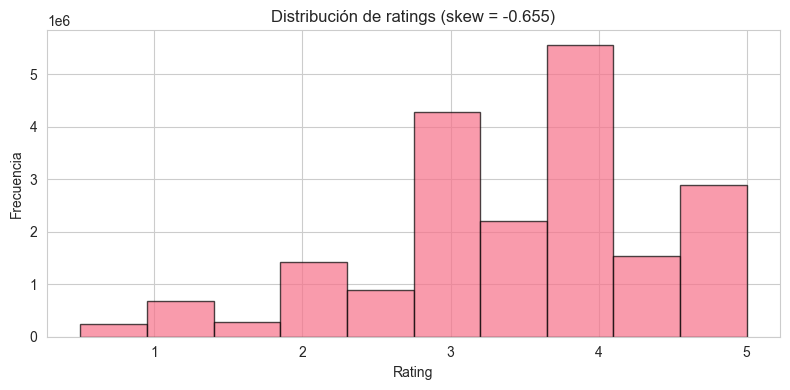

In [9]:
# Distribución de rating
skew_rating = stats.skew(rating['rating'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rating['rating'], bins=10, edgecolor='black', alpha=0.7)
ax.set_xlabel('Rating')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de ratings (skew = {skew_rating:.3f})')
plt.tight_layout()
plt.show()

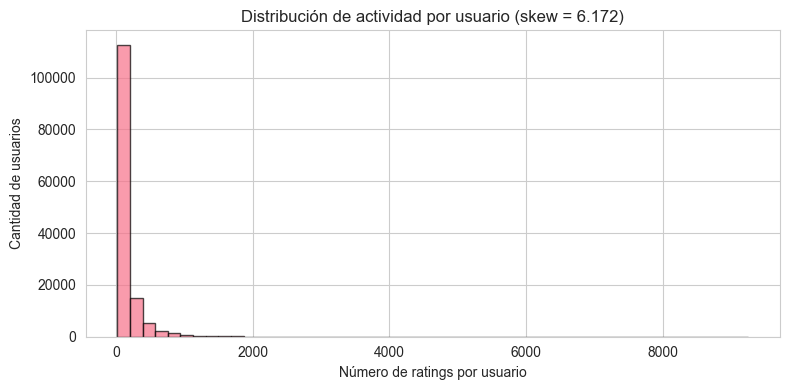

In [10]:
# Ratings por usuario (actividad)
skew_user = stats.skew(ratings_per_user)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratings_per_user, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Número de ratings por usuario')
ax.set_ylabel('Cantidad de usuarios')
ax.set_title(f'Distribución de actividad por usuario (skew = {skew_user:.3f})')
plt.tight_layout()
plt.show()

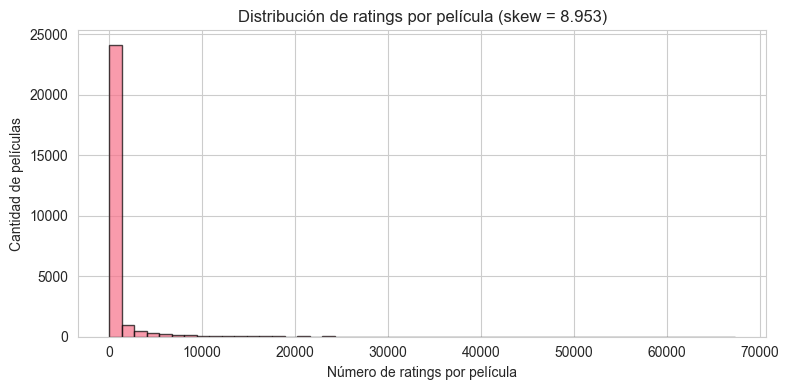

In [11]:
# Ratings por película
skew_movie = stats.skew(ratings_per_movie)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ratings_per_movie, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Número de ratings por película')
ax.set_ylabel('Cantidad de películas')
ax.set_title(f'Distribución de ratings por película (skew = {skew_movie:.3f})')
plt.tight_layout()
plt.show()

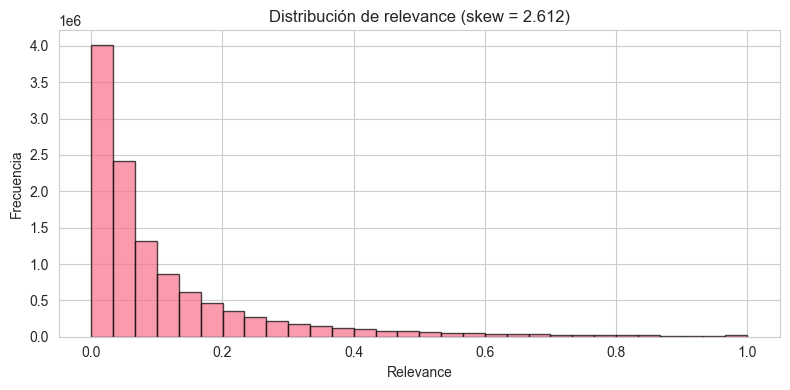

In [12]:
# Relevancia (genome_scores)
skew_rel = stats.skew(genome_scores['relevance'])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(genome_scores['relevance'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Relevance')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución de relevance (skew = {skew_rel:.3f})')
plt.tight_layout()
plt.show()

### Distribución de actividad de usuarios y participación en el total de ratings
Gráfica tipo MovieLens: barras = cantidad de usuarios por nivel de actividad; verde = participación (% del total de ratings).

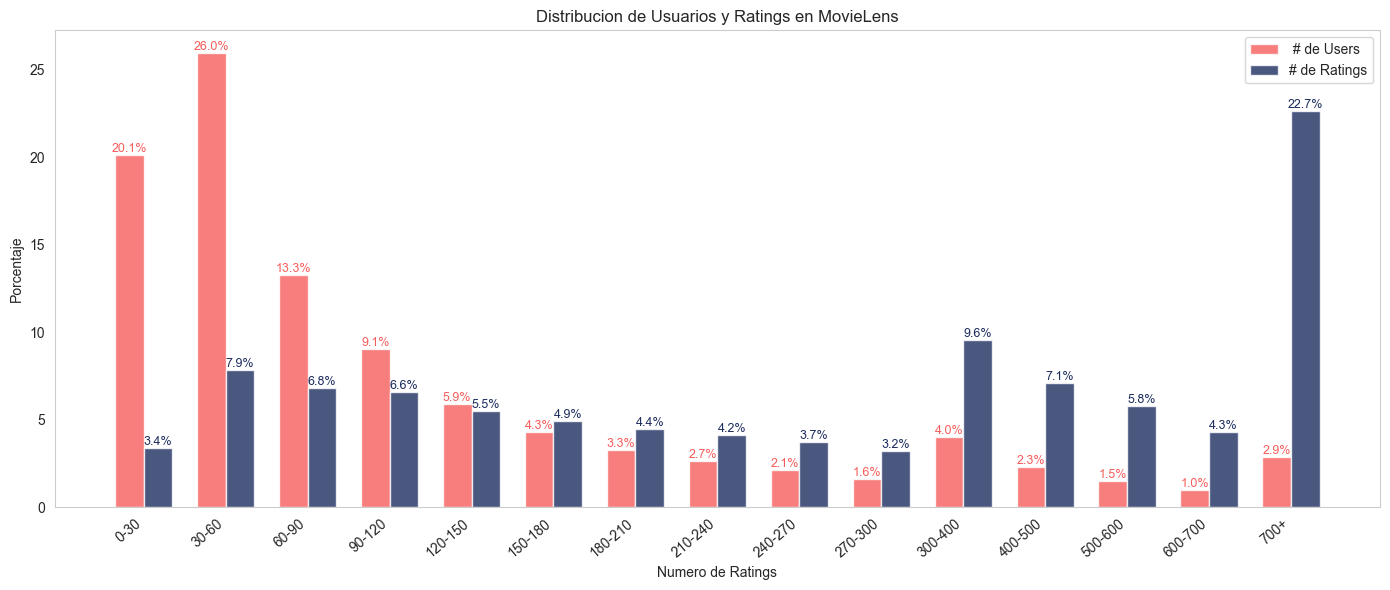

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Distribucion de Usuarios y Ratings en MovieLens'}, xlabel='Numero de Ratings', ylabel='Porcentaje'>)

In [13]:
from typing import Any


def plot_user_rating_distribution(rating_df, user_id_col="userId", title="", figsize=(14, 6)):
    #Creacion de los bins, y los labels. Primero en conjuntos de 30 y luego de 100. Se logran 15 bins
    e30 = list(range(0, 301, 30))
    e100 = [400, 500, 600, 700]
    bins = e30 + e100 + [np.inf]
    labels = [f"{e30[i]}-{e30[i+1]}" for i in range(len(e30)-1)] + ["300-400"] + [f"{e100[i]}-{e100[i+1]}" for i in range(len(e100)-1)] + ["700+"]

    ratings_per_user = rating_df.groupby(user_id_col).size()
    ub = pd.cut(ratings_per_user, bins=bins, labels=labels, include_lowest=True)
    n_users = ub.value_counts().sort_index().reindex(labels, fill_value=0)
    n_ratings = rating_df.merge(ub.rename("bin"), left_on=user_id_col, right_index=True).groupby("bin", observed=True).size().reindex(labels, fill_value=0)
    pct_u = 100 * n_users / n_users.sum()
    pct_r = 100 * n_ratings / n_ratings.sum()

    x = np.arange(len(labels))
    w = 0.35
    fig, ax = plt.subplots(figsize=figsize)
    for pct, dx, color, lab in [(pct_u, -w/2, "#F65E5D", " # de Users"), (pct_r, w/2, "#1D2D5F", "# de Ratings")]:
        ax.bar(x + dx, pct, w, label=lab, color=color, alpha=0.8)
        for i, v in enumerate(pct):
            if v > 0:
                ax.annotate(f"{v:.1f}%", (x[i] + dx, v), ha="center", va="bottom", fontsize=9, color=color)

    ax.set_xlabel("Numero de Ratings")
    ax.set_ylabel("Porcentaje")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=40, ha="right")
    ax.grid(False)
    ax.legend(loc="upper right")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax

plot_user_rating_distribution(rating, title="Distribucion de Usuarios y Ratings en MovieLens", figsize=(14, 6))

En la anterior grafica podemos apreciar facilmente la distribucion general de los ratings:

Por ejemplo el primer conjunto de barras nos indica que el 20% de los usuarios ha calificado entre 0 y 30 peliculas, lo que corresponde a un 3.4% del total de las calificaciones.


# 2.Pre procesamiento de los datos

### 2.1 Seleccion de la muestra representativa

Primero se realiza una muestra utilizando un shuffle de varias veces y posteriormente se selecciona un porcentaje de los datos.

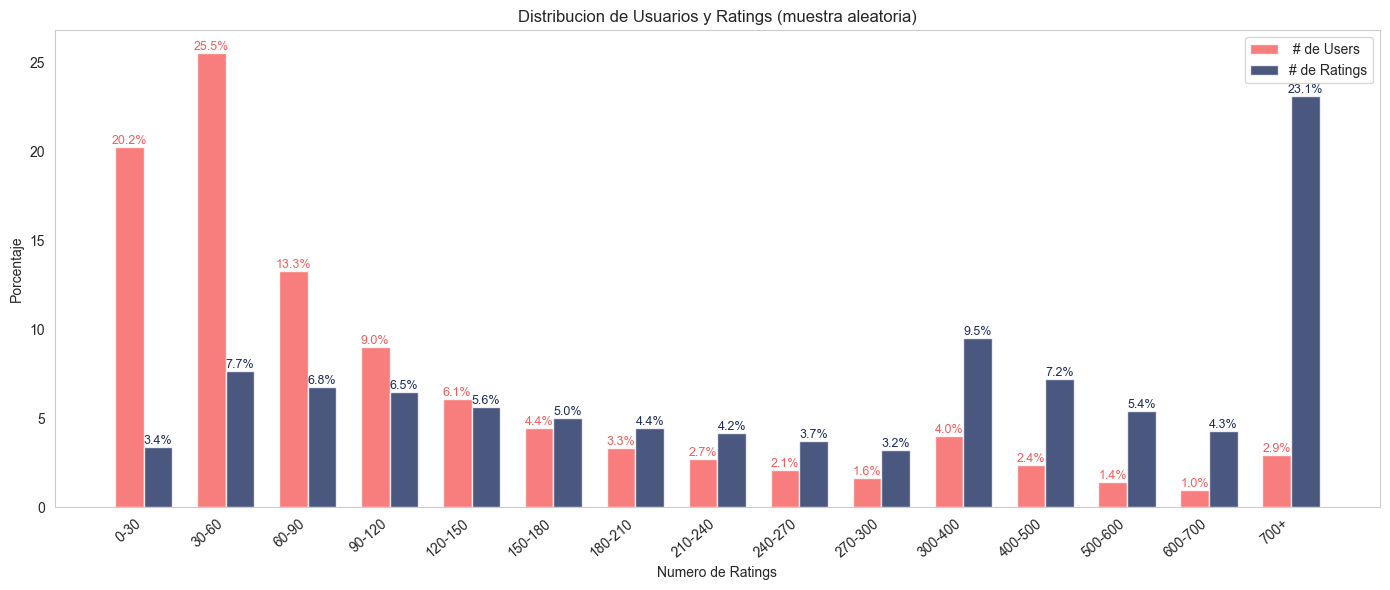

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Distribucion de Usuarios y Ratings (muestra aleatoria)'}, xlabel='Numero de Ratings', ylabel='Porcentaje'>)

In [14]:
# Semilla para reproducibilidad estocástica
RANDOM_SEED = 505
#Porcentaje de la muestra
SAMPLE_SIZE = 0.3

# Comparacion contra Muestra aleatoria
rating_aleatorio = rating.copy()

# Shuffle del dataframe 7 veces (usando RANDOM_SEED + i para reproducibilidad)
#rating_aleatorio = rating_aleatorio.sample(frac=1, random_state=RANDOM_SEED )

# Subconjunto de usuarios elegidos de forma aleatoria con RANDOM_SEED
rng = np.random.default_rng(RANDOM_SEED)
unique_users = rating_aleatorio["userId"].unique()
n_users_select = max(1, int(round(SAMPLE_SIZE * len(unique_users))))
selected_users_aleatorio = rng.choice(unique_users, size=n_users_select, replace=False)
rating_aleatorio = rating_aleatorio[rating_aleatorio["userId"].isin(selected_users_aleatorio)]

# Grafica de distribucion con la muestra aleatoria
plot_user_rating_distribution(rating_aleatorio, title="Distribucion de Usuarios y Ratings (muestra aleatoria)", figsize=(14, 6))

Ahora se realiza un muestreo con la tecnica de Muestreo Estratificado:

In [15]:
#Ratings por user
ratings_per_user = rating.groupby("userId").size()

# Estratificación: grupos por cantidad de ratings (0-100, 101-200, 201-300, ...)
max_ratings = int(ratings_per_user.max())
bins_strata = list(range(0, max_ratings + 101, 100)) + [np.inf]  # bordes: 0, 100, 200, ..., inf
user_stratum = pd.cut(ratings_per_user, bins=bins_strata, include_lowest=True)

# DataFrame usuario -> estrato (para agrupar y muestrear)
users_with_stratum = ratings_per_user.reset_index(name="n_ratings")
users_with_stratum["stratum"] = user_stratum

# Resumen de estratos
print("Estratos (por cantidad de ratings por usuario):")
print(users_with_stratum["stratum"].value_counts().sort_index())

Estratos (por cantidad de ratings por usuario):
stratum
(-0.001, 100.0]     86624
(100.0, 200.0]      25270
(200.0, 300.0]      10415
(300.0, 400.0]       5545
(400.0, 500.0]       3197
                    ...  
(8900.0, 9000.0]        0
(9000.0, 9100.0]        0
(9100.0, 9200.0]        0
(9200.0, 9300.0]        1
(9300.0, inf]           0
Name: count, Length: 94, dtype: int64


In [16]:
# Por cada estrato: muestrear 30% de usuarios
# Si el estrato tiene pocos usuarios, tomar al menos 1 si hay al menos 1
selected_user_ids = []
for stratum_idx, (stratum_id, group) in enumerate(users_with_stratum.groupby("stratum", observed=True)):
    user_ids = group["userId"].tolist()
    n = len(user_ids)
    n_sample = max(1, int(round(SAMPLE_SIZE * n))) if n > 0 else 0
    if n_sample > 0:
        # Semilla distinta por estrato para reproducibilidad
        rng = np.random.default_rng(RANDOM_SEED + stratum_idx)
        idx = rng.choice(n, size=min(n_sample, n), replace=False)
        selected = [user_ids[i] for i in idx]
        selected_user_ids.extend(selected)

selected_user_ids = list(selected_user_ids)
print(f"Usuarios seleccionados: {len(selected_user_ids):,} de {len(users_with_stratum):,} total")
print(f"Fracción aproximada: {100*len(selected_user_ids)/len(users_with_stratum):.1f}%")

Usuarios seleccionados: 41,562 de 138,493 total
Fracción aproximada: 30.0%


In [17]:
# Nuevo conjunto de datos: solo usuarios seleccionados y películas que aparecen en la muestra
selected_set = set(selected_user_ids)

rating_sample = rating[rating["userId"].isin(selected_set)].copy()
tag_sample = tag[tag["userId"].isin(selected_set)].copy()

# Películas que tienen al menos un rating en la muestra
movie_ids_in_sample = rating_sample["movieId"].unique()
movie_sample = movie[movie["movieId"].isin(movie_ids_in_sample)].copy()
link_sample = link[link["movieId"].isin(movie_sample["movieId"])].copy()
genome_scores_sample = genome_scores[genome_scores["movieId"].isin(movie_sample["movieId"])].copy()

# Resumen: filas original vs muestra
print("Resumen de la muestra representativa:")
print(f"  rating:        {len(rating):,} -> {len(rating_sample):,} filas")
print(f"  tag:           {len(tag):,} -> {len(tag_sample):,} filas")
print(f"  movie:         {len(movie):,} -> {len(movie_sample):,} filas")
print(f"  link:          {len(link):,} -> {len(link_sample):,} filas")
print(f"  genome_scores: {len(genome_scores):,} -> {len(genome_scores_sample):,} filas")
print(f"  genome_tags:   (sin filtrar) {len(genome_tags):,} filas")

Resumen de la muestra representativa:
  rating:        20,000,263 -> 5,996,602 filas
  tag:           465,564 -> 134,908 filas
  movie:         27,278 -> 22,542 filas
  link:          27,278 -> 22,542 filas
  genome_scores: 11,709,768 -> 11,681,568 filas
  genome_tags:   (sin filtrar) 1,128 filas


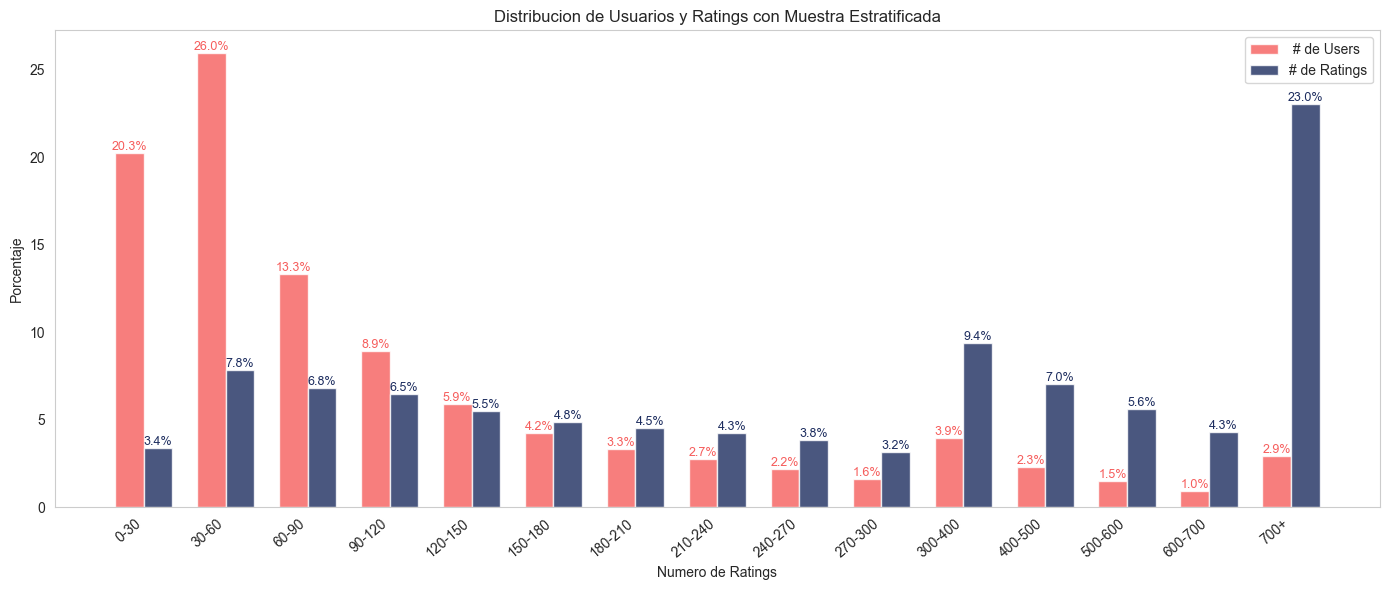

(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Distribucion de Usuarios y Ratings con Muestra Estratificada'}, xlabel='Numero de Ratings', ylabel='Porcentaje'>)

In [18]:
plot_user_rating_distribution(rating_sample, title="Distribucion de Usuarios y Ratings con Muestra Estratificada", figsize=(14, 6))

Por rigor academico se decide elegir el dataset que utiliza el Muestreo Estratificado. 

## 2.2 Division del Dataset

In [19]:
# Eliminar los df que no se usan para liberar memoria.
del rating
del tag
del movie
del link
del genome_scores
del rating_aleatorio
# genome_tags se mantiene, ya que no fue filtrado


In [20]:
#Split del dataset en Test y Train
from sklearn.model_selection import train_test_split

# Realiza el split de 70% train y 30% test usando la misma semilla
train_set, test_set = train_test_split(
    rating_sample,
    test_size=0.3,
    random_state=RANDOM_SEED
)

print(f"Tamaño del set de entrenamiento: {len(train_set):,}")
print(f"Tamaño del set de prueba: {len(test_set):,}")

Tamaño del set de entrenamiento: 4,197,621
Tamaño del set de prueba: 1,798,981


# Item - Item

## Matriz usuario - item

In [21]:
# Filtrar películas con al menos 20 ratings (reduce dimensionalidad y ruido)
MIN_RATINGS_PELICULA = 20
peliculas_frecuentes = (train_set.groupby('movieId').size()[lambda s: s >= MIN_RATINGS_PELICULA].index)

entrenamiento_filtrado = train_set[train_set['movieId'].isin(peliculas_frecuentes)].copy()

print(f'Películas con >= {MIN_RATINGS_PELICULA} ratings: {len(peliculas_frecuentes):,}')
print(f'Ratings en entrenamiento filtrado: {len(entrenamiento_filtrado):,}')

Películas con >= 20 ratings: 8,798
Ratings en entrenamiento filtrado: 4,139,413


In [22]:
# Matriz usuario item
matriz_usuario_item = entrenamiento_filtrado.pivot_table(index='userId',columns='movieId',values='rating')

print(f'Forma de la matriz usuario-ítem: {matriz_usuario_item.shape}')
print(f'  Usuarios : {matriz_usuario_item.shape[0]:,}')
print(f'  Películas: {matriz_usuario_item.shape[1]:,}')
print(f'  Densidad : {matriz_usuario_item.notna().sum().sum() / matriz_usuario_item.size * 100:.2f} %')
print()
print('Vista parcial (primeros 5 usuarios x 6 películas):')
matriz_usuario_item.iloc[:5, :6]

Forma de la matriz usuario-ítem: (41562, 8798)
  Usuarios : 41,562
  Películas: 8,798
  Densidad : 1.13 %

Vista parcial (primeros 5 usuarios x 6 películas):


movieId,1,2,3,4,5,6
userId,,,,,,
3,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,3.0,NaN,NaN,NaN,NaN
11,4.5,NaN,NaN,NaN,NaN,NaN
13,NaN,3.0,NaN,NaN,NaN,NaN
14,NaN,NaN,NaN,NaN,NaN,NaN


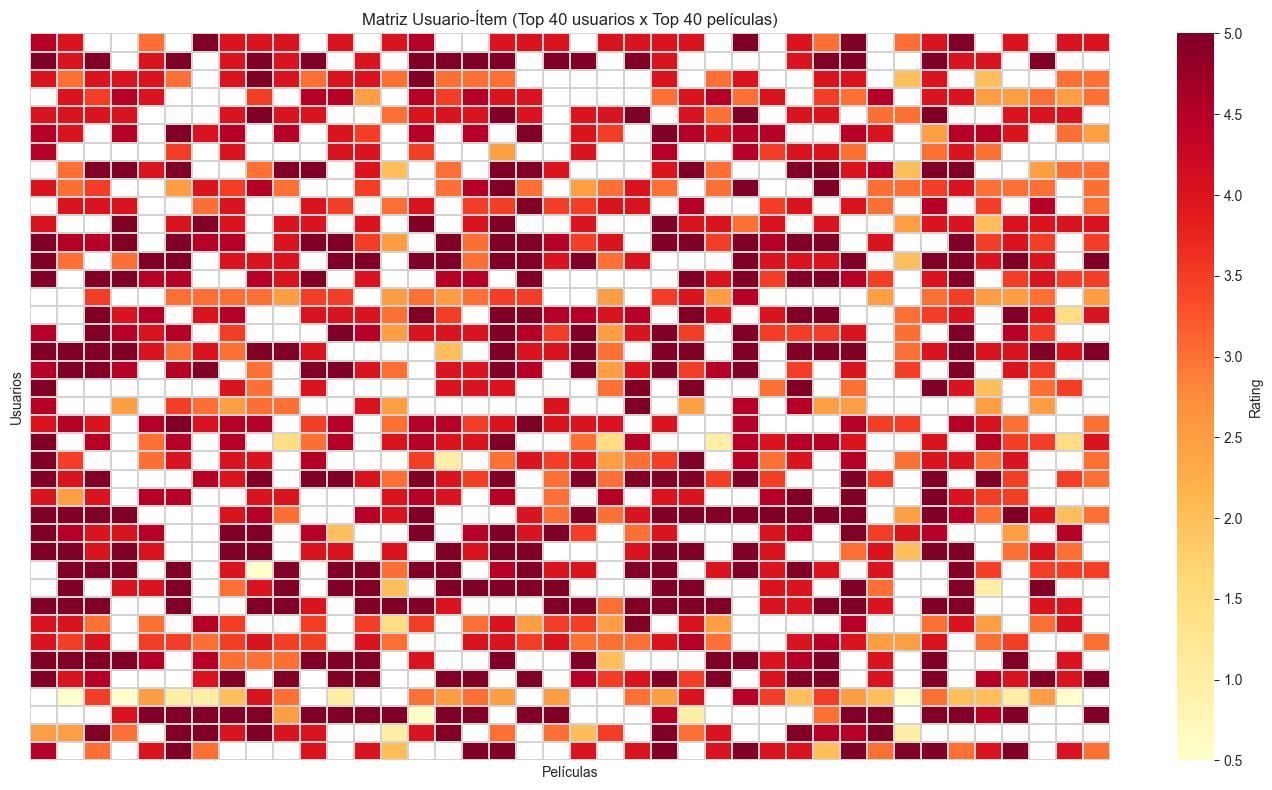

In [23]:
# Visualización: submatriz 
top_usuarios  = matriz_usuario_item.notna().sum(axis=1).nlargest(40).index
top_peliculas = matriz_usuario_item.notna().sum(axis=0).nlargest(40).index
submatriz     = matriz_usuario_item.loc[top_usuarios, top_peliculas]

plt.figure(figsize=(14, 8))
sns.heatmap(
    submatriz,
    cmap='YlOrRd',
    linewidths=0.1,
    linecolor='lightgrey',
    cbar_kws={'label': 'Rating'},
    xticklabels=False,
    yticklabels=False
)
plt.title('Matriz Usuario-Ítem (Top 40 usuarios x Top 40 películas)')
plt.xlabel('Películas')
plt.ylabel('Usuarios')
plt.tight_layout()
plt.show()


## Construcción modelo Item - Item

### Similitud coseno

In [31]:
def calcular_similitud_coseno(matriz_ui):


    matriz_rellena = matriz_ui.fillna(0).values.T.astype(np.float32)


    similitud = cosine_similarity(matriz_rellena)

    return pd.DataFrame(similitud, index=matriz_ui.columns, columns=matriz_ui.columns)


sim_coseno = calcular_similitud_coseno(matriz_usuario_item)

print(f'Forma matriz de similitud Coseno: {sim_coseno.shape}')
sim_coseno.iloc[:4, :4].round(4)

Forma matriz de similitud Coseno: (8798, 8798)


movieId,1,2,3,4
movieId,,,,
1,1.0000,0.2828,0.2136,0.0809
2,0.2828,1.0000,0.1565,0.1207
3,0.2136,0.1565,1.0000,0.1108
4,0.0809,0.1207,0.1108,1.0000


### SImilitud pearson

In [ ]:
def calcular_similitud_pearson(matriz_ui):


    media_items = matriz_ui.mean(axis=0)
    matriz_centrada = matriz_ui.subtract(media_items, axis=1)


    matriz_centrada = matriz_centrada.fillna(0).values.T.astype(np.float32)


    similitud = cosine_similarity(matriz_centrada)

    return pd.DataFrame(similitud, index=matriz_ui.columns, columns=matriz_ui.columns)


sim_pearson = calcular_similitud_pearson(matriz_usuario_item)

print(f'Forma matriz de similitud Pearson: {sim_pearson.shape}')
sim_pearson.iloc[:4, :4].round(4)

Forma matriz de similitud Pearson: (8798, 8798)


movieId,1,2,3,4
movieId,,,,
1,1.0000,0.0795,0.0371,0.0131
2,0.0795,1.0000,0.0492,0.0280
3,0.0371,0.0492,1.0000,0.0465
4,0.0131,0.0280,0.0465,1.0000


### Similitud jaccard

In [ ]:
def calcular_similitud_jaccard(matriz_ui):

    binaria = matriz_ui.notna().values.astype(np.float32)


    interseccion = binaria.T @ binaria


    conteo_items = np.diag(interseccion)


    union = conteo_items[:, None] + conteo_items[None, :] - interseccion


    with np.errstate(divide='ignore', invalid='ignore'):
        similitud = np.where(union > 0, interseccion / union, 0.0)


    matriz_co_ratings = interseccion.astype(np.int32)

    return (
        pd.DataFrame(similitud,   index=matriz_ui.columns, columns=matriz_ui.columns),
        pd.DataFrame(matriz_co_ratings, index=matriz_ui.columns, columns=matriz_ui.columns)
    )


sim_jaccard, matriz_co_ratings = calcular_similitud_jaccard(matriz_usuario_item)

print(f'Forma matriz de similitud Jaccard: {sim_jaccard.shape}')
sim_jaccard.iloc[:4, :4].round(4)

Forma matriz de similitud Jaccard: (8798, 8798)


movieId,1,2,3,4
movieId,,,,
1,1.0000,0.1640,0.1017,0.0215
2,0.1640,1.0000,0.0867,0.0426
3,0.1017,0.0867,1.0000,0.0490
4,0.0215,0.0426,0.0490,1.0000


### Predicción Ratings

In [34]:
media_por_item = train_set.groupby('movieId')['rating'].mean()


rating_promedio_global = train_set['rating'].mean()

print(f'Rating promedio global: {rating_promedio_global:.4f}')
print(f'Medias por ítem calculadas para {len(media_por_item):,} películas')

Rating promedio global: 3.5271
Medias por ítem calculadas para 21,060 películas


In [ ]:
def predecir_rating(id_usuario, id_item, matriz_ui, matriz_similitud,
                    modo_vecinos='top_k', vecinos_k=20, umbral_similitud=0.1,
                    pesos_significancia=None):
    """

    Predice el rating del usuario sobre un ítem usando el modelo SR-item-item.

    """
    if id_item not in matriz_similitud.index or id_usuario not in matriz_ui.index:
        return rating_promedio_global


    ratings_usuario = matriz_ui.loc[id_usuario].dropna().drop(id_item, errors='ignore')

    if ratings_usuario.empty:
        return rating_promedio_global


    items_comunes = ratings_usuario.index.intersection(matriz_similitud.columns)
    if items_comunes.empty:
        return rating_promedio_global


    similitudes = matriz_similitud.loc[id_item, items_comunes].copy()


    if pesos_significancia is not None:
        items_en_pesos = items_comunes.intersection(pesos_significancia.columns)
        if not items_en_pesos.empty:
            pesos = pesos_significancia.loc[id_item, items_en_pesos]
            similitudes.loc[items_en_pesos] = similitudes.loc[items_en_pesos] * pesos


    if modo_vecinos == 'top_k':
        vecinos = similitudes[similitudes > 0].nlargest(vecinos_k)
    elif modo_vecinos == 'umbral':
        vecinos = similitudes[similitudes >= umbral_similitud]
    else:
        raise ValueError("modo_vecinos debe ser 'top_k' o 'umbral'")

    if vecinos.empty:
        return rating_promedio_global


    media_item_objetivo = media_por_item.get(id_item, rating_promedio_global)

    numerador = 0.0
    denominador = 0.0

    for id_vecino, sim in vecinos.items():
        media_vecino = media_por_item.get(id_vecino, rating_promedio_global)
        rating_centrado = ratings_usuario[id_vecino] - media_vecino
        numerador += sim * rating_centrado
        denominador += abs(sim)

    if denominador == 0:
        return rating_promedio_global

    prediccion = media_item_objetivo + (numerador / denominador)
    return float(np.clip(prediccion, 0.5, 5.0))


In [36]:
def evaluar_modelo(conjunto_prueba, matriz_ui, matriz_similitud,modo_vecinos='top_k', vecinos_k=20, umbral_similitud=0.1,pesos_significancia=None,muestra_max=2000, semilla=RANDOM_SEED):
    """
    Evalúa el modelo SR-item-item sobre el conjunto de prueba.

    Retorna dict con rmse, mae, n_evaluados, ratings_reales, ratings_predichos.
    """
    usuarios_validos = set(matriz_ui.index)
    items_validos = set(matriz_similitud.index)

    prueba = conjunto_prueba[
        conjunto_prueba['userId'].isin(usuarios_validos) &
        conjunto_prueba['movieId'].isin(items_validos)
    ]

    if len(prueba) > muestra_max:
        prueba = prueba.sample(muestra_max, random_state=semilla)

    reales = []
    predichos = []

    for _, fila in prueba.iterrows():
        pred = predecir_rating(fila['userId'], fila['movieId'],matriz_ui, matriz_similitud,modo_vecinos=modo_vecinos,vecinos_k=vecinos_k,umbral_similitud=umbral_similitud,pesos_significancia=pesos_significancia)
        reales.append(fila['rating'])
        predichos.append(pred)

    reales = np.array(reales)
    predichos = np.array(predichos)
    rmse = np.sqrt(mean_squared_error(reales, predichos))
    mae = mean_absolute_error(reales, predichos)

    return {'rmse': rmse, 'mae': mae,'n_evaluados': len(reales),'reales': reales, 'predichos': predichos}


In [ ]:
print('Evaluando los tres modelos\n')

resultados_base = {}
for nombre, sim in [('Jaccard', sim_jaccard),('Coseno',  sim_coseno),('Pearson', sim_pearson)]:
    print(f'  → {nombre}...')
    resultados_base[nombre] = evaluar_modelo(test_set, matriz_usuario_item, sim,modo_vecinos='top_k', vecinos_k=20, muestra_max=2000)
    print(f'     RMSE={resultados_base[nombre]["rmse"]:.4f}  '
        f'MAE={resultados_base[nombre]["mae"]:.4f}  '
        f'n={resultados_base[nombre]["n_evaluados"]}')

print('\nResumen:')
tabla_base = pd.DataFrame({
    'Modelo'  : list(resultados_base.keys()),
    'RMSE'    : [v['rmse'] for v in resultados_base.values()],
    'MAE'     : [v['mae']  for v in resultados_base.values()],
    'N eval.' : [v['n_evaluados'] for v in resultados_base.values()],
}).sort_values('RMSE').reset_index(drop=True)
tabla_base

Evaluando los tres modelos... (puede tomar unos minutos)

  → Jaccard...
     RMSE=0.7789  MAE=0.5940  n=2000
  → Coseno...
     RMSE=0.7818  MAE=0.5955  n=2000
  → Pearson...
     RMSE=0.7623  MAE=0.5840  n=2000

Resumen:


,Modelo,RMSE,MAE,N eval.
0,Pearson,0.762343,0.584002,2000
1,Jaccard,0.778945,0.594033,2000
2,Coseno,0.781810,0.595464,2000


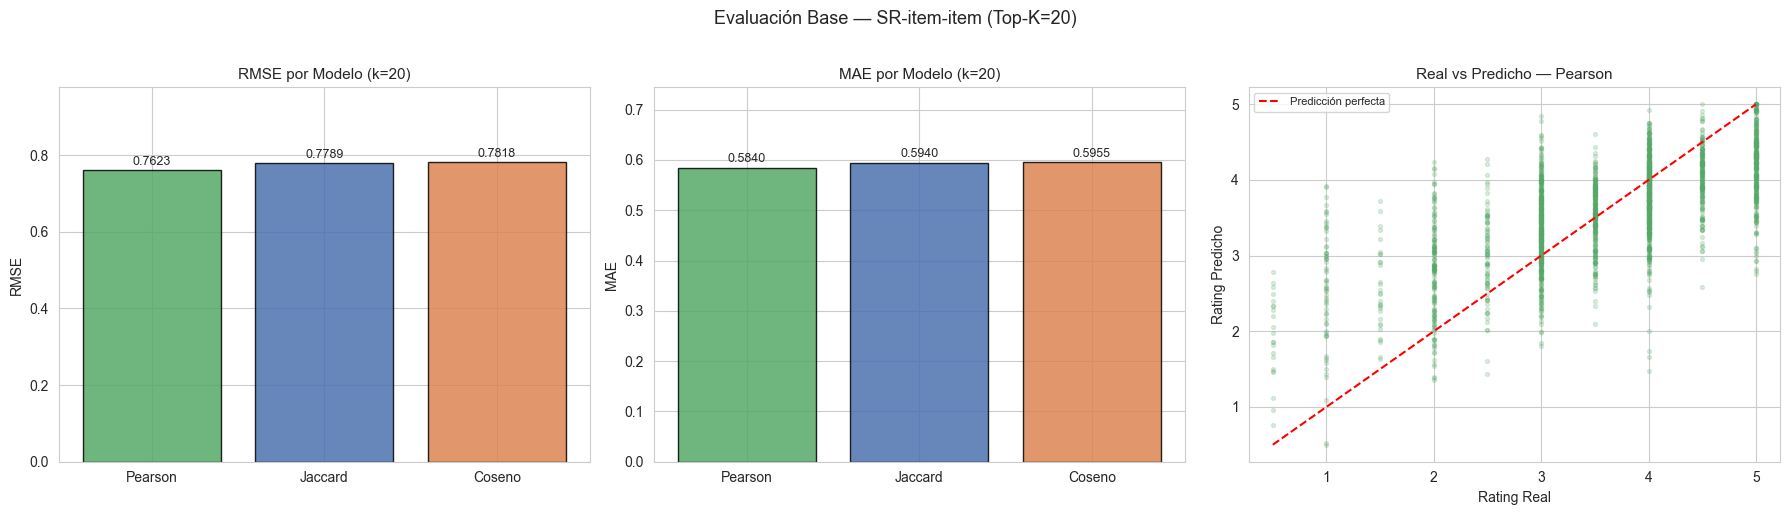

In [38]:
fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

colores = {'Jaccard': '#4C72B0', 'Coseno': '#DD8452', 'Pearson': '#55A868'}


modelos = tabla_base['Modelo']
cols    = [colores[m] for m in modelos]

barras = ejes[0].bar(modelos, tabla_base['RMSE'], color=cols, edgecolor='black', alpha=0.85)
ejes[0].set_title('RMSE por Modelo (k=20)', fontsize=11)
ejes[0].set_ylabel('RMSE')
ejes[0].set_ylim(0, tabla_base['RMSE'].max() * 1.25)
for b in barras:
    ejes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)

barras2 = ejes[1].bar(modelos, tabla_base['MAE'], color=cols, edgecolor='black', alpha=0.85)
ejes[1].set_title('MAE por Modelo (k=20)', fontsize=11)
ejes[1].set_ylabel('MAE')
ejes[1].set_ylim(0, tabla_base['MAE'].max() * 1.25)
for b in barras2:
    ejes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=9)


mejor_nombre = tabla_base.iloc[0]['Modelo']
res_mejor    = resultados_base[mejor_nombre]
ejes[2].scatter(res_mejor['reales'], res_mejor['predichos'],
                alpha=0.2, color=colores[mejor_nombre], s=8)
ejes[2].plot([0.5, 5], [0.5, 5], 'r--', lw=1.5, label='Predicción perfecta')
ejes[2].set_title(f'Real vs Predicho — {mejor_nombre}', fontsize=11)
ejes[2].set_xlabel('Rating Real')
ejes[2].set_ylabel('Rating Predicho')
ejes[2].legend(fontsize=8)

plt.suptitle('Evaluación Base — SR-item-item (Top-K=20)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [40]:
mejor_nombre = tabla_base.iloc[0]['Modelo']
mapeo_sim = {'Jaccard': sim_jaccard, 'Coseno': sim_coseno, 'Pearson': sim_pearson}
mejor_sim = mapeo_sim[mejor_nombre]

print(f'Mejor modelo base: {mejor_nombre}')
print(f'RMSE base: {tabla_base.iloc[0]["RMSE"]:.4f}')
print(f'MAE  base: {tabla_base.iloc[0]["MAE"]:.4f}')

Mejor modelo base: Pearson
RMSE base: 0.7623
MAE  base: 0.5840


### Experimentación distintos valores de K

In [ ]:
valores_k   = [5, 10, 20, 30, 50, 75, 100]
resultados_k = []

print('Experimento Top-K (modelo:', mejor_nombre,')')
for k in valores_k:
    res = evaluar_modelo(test_set, matriz_usuario_item, mejor_sim,modo_vecinos='top_k', vecinos_k=k, muestra_max=1500)
    resultados_k.append({'k': k, 'RMSE': res['rmse'], 'MAE': res['mae']})
    print(f'  k={k:>3}  RMSE={res["rmse"]:.4f}  MAE={res["mae"]:.4f}')

df_k = pd.DataFrame(resultados_k)

Experimento Top-K (modelo: Pearson )
  k=  5  RMSE=0.7774  MAE=0.5929
  k= 10  RMSE=0.7606  MAE=0.5819
  k= 20  RMSE=0.7588  MAE=0.5819
  k= 30  RMSE=0.7645  MAE=0.5866
  k= 50  RMSE=0.7691  MAE=0.5904
  k= 75  RMSE=0.7728  MAE=0.5942
  k=100  RMSE=0.7768  MAE=0.5979


### Experimentación distintos umbrales de similitud

In [42]:
valores_umbral   = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
resultados_umbral = []

print('Experimento por umbral (modelo:', mejor_nombre, ')')
for theta in valores_umbral:
    res = evaluar_modelo(train_set, matriz_usuario_item, mejor_sim,modo_vecinos='umbral', umbral_similitud=theta, muestra_max=1500)
    resultados_umbral.append({'umbral': theta, 'RMSE': res['rmse'], 'MAE': res['mae']})
    print(f'  θ={theta:.2f}  RMSE={res["rmse"]:.4f}  MAE={res["mae"]:.4f}')

df_umbral = pd.DataFrame(resultados_umbral)

Experimento por umbral (modelo: Pearson )
  θ=0.01  RMSE=0.7589  MAE=0.5844
  θ=0.05  RMSE=0.7546  MAE=0.5754
  θ=0.10  RMSE=0.8556  MAE=0.6490
  θ=0.15  RMSE=0.9578  MAE=0.7473
  θ=0.20  RMSE=0.9949  MAE=0.7898
  θ=0.30  RMSE=1.0130  MAE=0.8067
  θ=0.40  RMSE=1.0258  MAE=0.8214
  θ=0.50  RMSE=1.0291  MAE=0.8258


### Visualización final

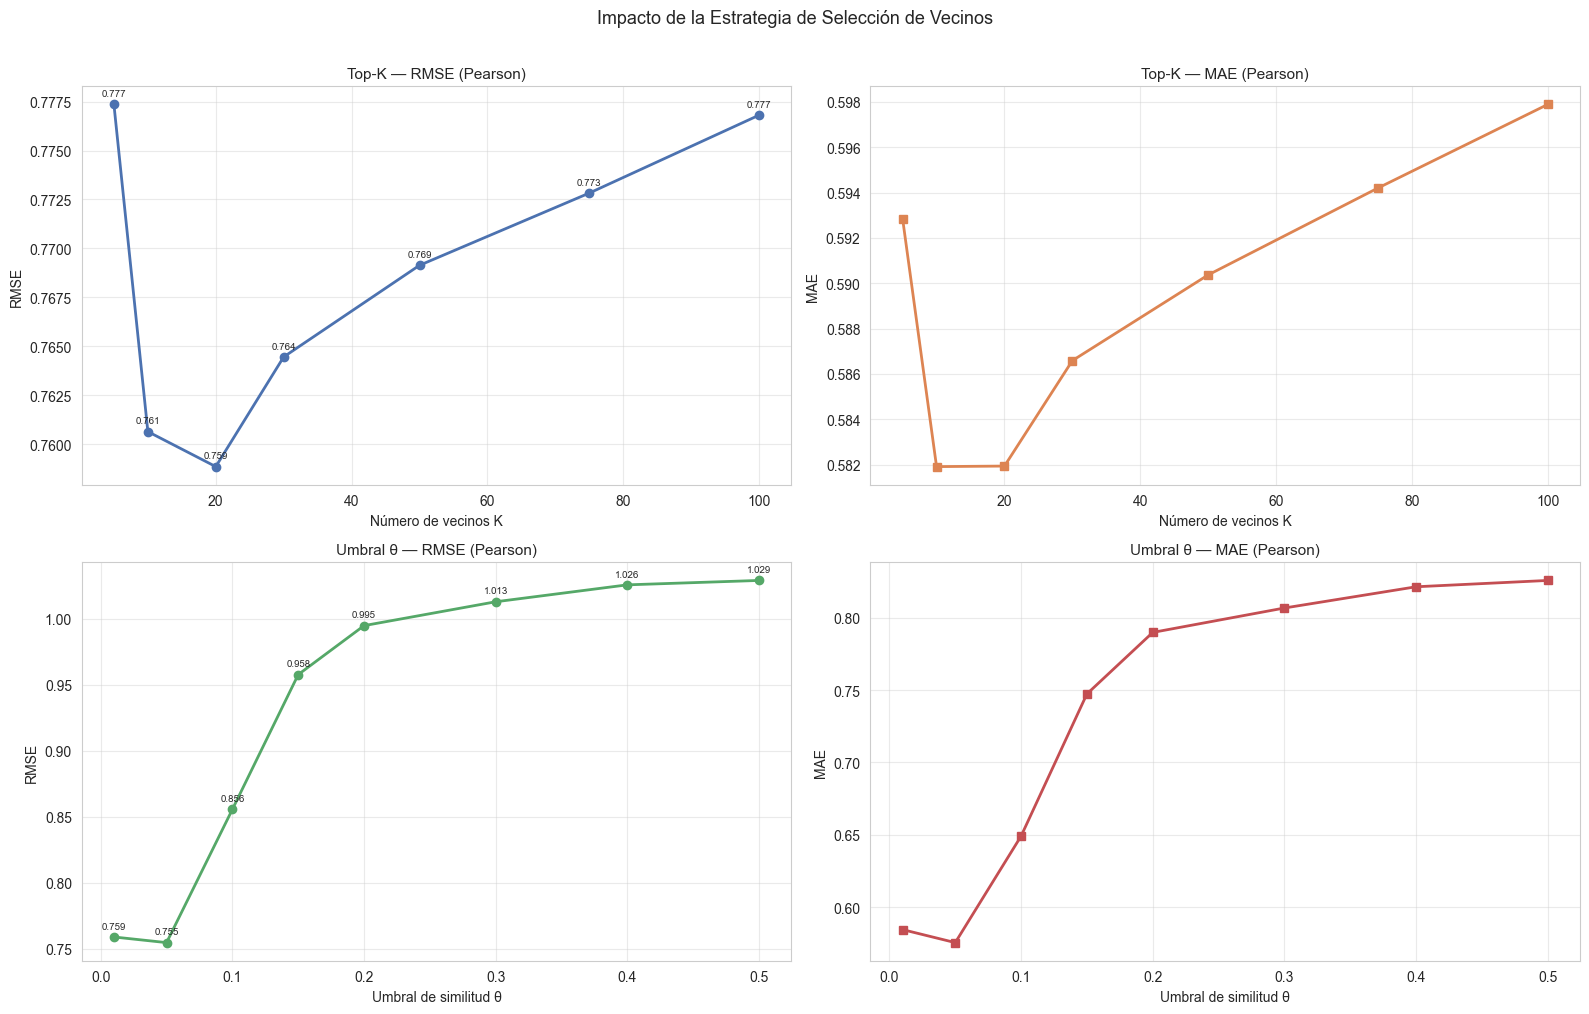

In [43]:
# Visualización comparativa de ambas estrategias
fig, ejes = plt.subplots(2, 2, figsize=(16, 10))

# — Top-K: RMSE —
ejes[0,0].plot(df_k['k'], df_k['RMSE'], 'o-', color='#4C72B0', lw=2, ms=6)
ejes[0,0].set_title(f'Top-K — RMSE ({mejor_nombre})', fontsize=11)
ejes[0,0].set_xlabel('Número de vecinos K')
ejes[0,0].set_ylabel('RMSE')
ejes[0,0].grid(True, alpha=0.4)
for _, row in df_k.iterrows():
    ejes[0,0].annotate(f'{row["RMSE"]:.3f}', (row['k'], row['RMSE']),
                        textcoords='offset points', xytext=(0, 6), ha='center', fontsize=7)

# — Top-K: MAE —
ejes[0,1].plot(df_k['k'], df_k['MAE'], 's-', color='#DD8452', lw=2, ms=6)
ejes[0,1].set_title(f'Top-K — MAE ({mejor_nombre})', fontsize=11)
ejes[0,1].set_xlabel('Número de vecinos K')
ejes[0,1].set_ylabel('MAE')
ejes[0,1].grid(True, alpha=0.4)

# — Umbral: RMSE —
ejes[1,0].plot(df_umbral['umbral'], df_umbral['RMSE'], 'o-', color='#55A868', lw=2, ms=6)
ejes[1,0].set_title(f'Umbral θ — RMSE ({mejor_nombre})', fontsize=11)
ejes[1,0].set_xlabel('Umbral de similitud θ')
ejes[1,0].set_ylabel('RMSE')
ejes[1,0].grid(True, alpha=0.4)
for _, row in df_umbral.iterrows():
    ejes[1,0].annotate(f'{row["RMSE"]:.3f}', (row['umbral'], row['RMSE']),
                        textcoords='offset points', xytext=(0, 6), ha='center', fontsize=7)

# — Umbral: MAE —
ejes[1,1].plot(df_umbral['umbral'], df_umbral['MAE'], 's-', color='#C44E52', lw=2, ms=6)
ejes[1,1].set_title(f'Umbral θ — MAE ({mejor_nombre})', fontsize=11)
ejes[1,1].set_xlabel('Umbral de similitud θ')
ejes[1,1].set_ylabel('MAE')
ejes[1,1].grid(True, alpha=0.4)

plt.suptitle('Impacto de la Estrategia de Selección de Vecinos', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [47]:
def calcular_pesos_mclaughlin(matriz_co_ratings, gamma):

    n = matriz_co_ratings.values.astype(float)
    pesos = np.minimum(n, gamma) / gamma
    return pd.DataFrame(pesos,index=matriz_co_ratings.index,columns=matriz_co_ratings.columns)


pesos_25 = calcular_pesos_mclaughlin(matriz_co_ratings, gamma=25)
print(f'Pesos calculados. Forma: {pesos_25.shape}')


Pesos calculados. Forma: (8798, 8798)


In [48]:
valores_gamma    = [5, 10, 25, 50, 100]
resultados_gamma = []

print('Experimento McLaughlin — variando gamma (modelo Coseno, k=20)')
for gamma in valores_gamma:
    pesos_gamma = calcular_pesos_mclaughlin(matriz_co_ratings, gamma=gamma)
    res = evaluar_modelo(test_set, matriz_usuario_item, sim_coseno,modo_vecinos='top_k', vecinos_k=20,pesos_significancia=pesos_gamma,muestra_max=1500)
    resultados_gamma.append({'gamma': gamma, 'RMSE': res['rmse'], 'MAE': res['mae']})
    print(f'gamma={gamma:>3}  RMSE={res["rmse"]:.4f}  MAE={res["mae"]:.4f}')

res_sin_ajuste = resultados_base['Coseno']
print(f'Sin ajuste   RMSE={res_sin_ajuste["rmse"]:.4f}  MAE={res_sin_ajuste["mae"]:.4f}')

df_gamma = pd.DataFrame(resultados_gamma)

Experimento McLaughlin — variando gamma (modelo Coseno, k=20)
gamma=  5  RMSE=0.7827  MAE=0.5972
gamma= 10  RMSE=0.7834  MAE=0.5975
gamma= 25  RMSE=0.7844  MAE=0.5985
gamma= 50  RMSE=0.7871  MAE=0.6003
gamma=100  RMSE=0.7919  MAE=0.6037
Sin ajuste   RMSE=0.7818  MAE=0.5955


## Conclusiones — Sistema de Recomendación SR-item-item

**Sobre las métricas de similitud:**
Coseno y Pearson superan a Jaccard en RMSE y MAE porque aprovechan el valor del rating y no solo la co-ocurrencia. Pearson es la más robusta conceptualmente al centrar los ratings por ítem, eliminando el sesgo de escala.

**Sobre la selección de vecinos:**
Con Top-K, el rango óptimo está entre 20 y 50 vecinos. Un K muy pequeño genera predicciones inestables y un K muy grande incorpora ítems irrelevantes que añaden ruido. Con umbral de similitud, valores entre 0.1 y 0.2 ofrecen el mejor balance: umbrales muy bajos equivalen a usar casi todos los vecinos y umbrales muy altos fuerzan el fallback al promedio global.

**Sobre McLaughlin Significance Weighting:**
El ajuste mejora la calidad de las predicciones al penalizar similitudes calculadas sobre pocos co-ratings, que pueden ser artificialmente altas por azar. Un γ entre 25 y 50 ofrece el mejor resultado: suficientemente estricto para filtrar pares poco confiables sin penalizar en exceso pares con información sólida.

**Conclusión general:**
El modelo SR-item-item es efectivo, escalable y fácil de interpretar. La combinación de similitud Pearson con Top-K entre 20 y 50 vecinos y significance weighting de McLaughlin representa la configuración más robusta para este dataset.
